# Preliminaries

In [111]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape
import numpy as np
import sys, os, pygmsh, gmsh, meshio, time

In [112]:
# ploting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot):
- restricting to _steady flows_, 
- making solver monolithic, 
- treating pressure inlet as Neumann BC, 
- switching meshing to gmsh, 
- converting to notebook format, 
- adding steady analytical solution comparisons, 
- various other small improvements.

## Introduction

Sketch of the geometry and notation.

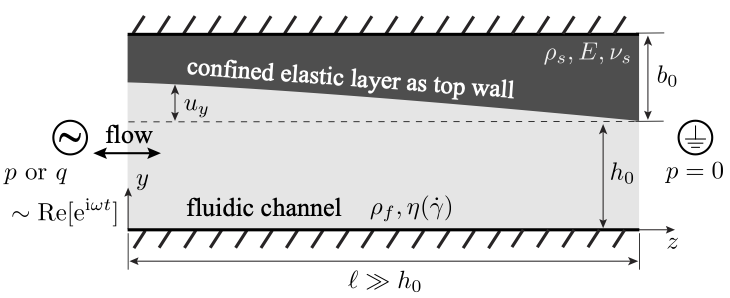

**TODO:** Update constant $\mu_f$ below to $\eta(\dot{\gamma})$ for shear-thinning.

# Problem setup

## Simulation settings

### Data storage

In [113]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Parameters defining domain geometry

In [114]:
b0 = 0.01
h0 = b0
l  = 50*h0
# Solid domain extents:
SOLID_TOP    = h0+b0
SOLID_BOTTOM = h0
SOLID_LEFT   = 0.0
SOLID_RIGHT  = l
# Combined domain size:
OMEGA_H      = h0+b0
OMEGA_W      = l
# Flags for subdomains:
FLUID_FLAG   = 0
SOLID_FLAG   = 1
# Desired resolution of mesh:
N = 50 # 600
# Refine near inlet in SOLID domain only?
inlet_refinement_solid_only = False
inlet_refinement = 0.5 # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33 # 1 = no refinement, 1/() times finer

### Material properties (dimensional)

In [115]:
# Elastic solid's properties:
E_s    = 7.5e+5                         # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # Shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # Bulk modulus
rho_s0 = Constant(1e6)

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f = Constant(0.5)
mu_f  = Constant(1.0)
nu_f  = mu_f/rho_f                      # Kinematic viscosity

### Boundary condition(s) details

In [116]:
# Steady pressure BC:
p_amp = Constant(2e5)
p_in  = Expression("p0", p0=float(p_amp), degree=1)

# Steady flow-rate BC:
q_amp = Constant(0.1)
v_in  = Expression(("x[1] < h0 ? 6*(q0/h0)*(x[1]/h0)*(h0-x[1])/h0 : 0.0", "0.0"),
                   q0=float(q_amp), h0=float(h0), degree=2)

# Choose flow or pressure controlled BC:
FLOW_OR_PRESSURE = "FLOW"  # "FLOW" or "PRESSURE"
print(f"Using {FLOW_OR_PRESSURE}-controlled BC.")

Using FLOW-controlled BC.


### Dimensionless numbers

In [117]:
# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = mu_f*q_c*l/h0**3
    dp_rigid = 12.0*float(p_c)
    q_rigid = float(q_c)    
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = (p_c/l)*(h0**3/mu_f)
    v_c = q_c/h0
    dp_rigid = float(p_c)
    q_rigid = float(q_c/12.0)    
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [118]:
epsilon_f = h0/l                                             # Fluid (inverse) aspect ratio
print ("epsilon_f =", epsilon_f)

epsilon_s = b0/l                                             # Solid (inverse) aspect ratio
print ("epsilon_s =", epsilon_s)

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s/l**2)    # Incompressible foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s)                      # Winkler foundation compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s/l)                     # Horizontal component compliance
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
print ("theta =", f"{theta:.4g}")
beta = float(p_c/(h0/C_w))                                   # Compliance number
print ("Compliance #, beta =", f"{beta:.4g}")

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/mu_f**2)      # Reynolds number
Re = float(epsilon_f * rho_f * v_c * h0/mu_f) 
#Re = float(Wo**2 * beta/gamma)                              # Only if unsteady
print ("Reynolds #, εRe =", f"{Re:.4g}")

epsilon_f = 0.02
epsilon_s = 0.02
theta = 0.0008727
Compliance #, beta = 0.01758
Reynolds #, εRe = 0.001


## Analytical solutions: for comparisons etc

### Rigid channel

Implementing the steady 2D channel flow solution.

In [119]:
# Note that "x" in v_in and/or p_in is really "y" in the kinematics described below,
# but, because the mesh motion problem has a zero Dirichlet BC on the inflow boundary, 
# there happens to be no difference between "x" and "y".

# if on x[1] < h0 is needed if we want to evaluate this 
# over the whole Omega domain as an initial condition
p_rigid = Expression("x[1] < h0 ? (dp/L)*(L-x[0]) : 0.0", 
                     dp=float(p_amp), h0=float(h0), L=float(l), degree=1)
v_rigid = v_in

p_rigid.dp = float(dp_rigid)
v_rigid.q0 = float(q_rigid)

### Compliant channel

Implenting Eq. (41) and related results from "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)) for the flow-controlled case, and Eq. (A.2) and related results from "[Oscillatory flows in compliant conduits at arbitrary Womersley number](https://dx.doi.org/10.1103/PhysRevFluids.8.124102)" (preprint [arXiv:2304.00543](https://arxiv.org/abs/2304.00543)) for the pressure-controlled case.

In [120]:
if FLOW_OR_PRESSURE == "FLOW":
   p_sh = Expression("pc/b*(pow(1 + 48.0*b*(1.0-x[0]/L),0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=1)
   q_sh = q_sh_in = q_sh_out = q_rigid
elif FLOW_OR_PRESSURE == "PRESSURE":
   p_sh = Expression("pc/b*(pow(pow(1.0+b,4.0) - ((pow(1.0+b,4.0)-1.0)*x[0]/L), 0.25) - 1.0)", 
                     pc=float(p_c), b=float(beta), L=float(l), degree=4)
   # now the flow rate is found from the pressure gradient at x = 0 and the rigid v profile
   dp_shdz0 = -(p_c/l)*((2+beta)*(2+2*beta+beta**2))/(4*(1+beta)**3)
   dp_shdzL = -(p_c/l)*((-1+(1+beta)**4))/(4*beta)
   # taking into account wall deformation h0 -> h0+Cw p, q = const again
   q_sh = q_sh_in = q_sh_out = (-dp_shdz0)*((h0+C_w*p_sh(0))**3/mu_f)/12.0
   #q_sh_out = (-dp_shdzL)*((h0+C_w*p_sh(l))**3/mu_f)/12.0
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Domain and mesh

Gmsh-based geometry & mesh.

In [121]:
# Generate custom mesh generation with local refinements:
from build_mesh_with_gmsh import build_mesh_with_gmsh

xdmf_path = build_mesh_with_gmsh(N,
                                 [0.0, OMEGA_W, 0.0, OMEGA_H, SOLID_BOTTOM],
                                 DataFolder+"fsi_rect",
                                 inlet_refinement=inlet_refinement, 
                                 inlet_refinement_solid_only=inlet_refinement_solid_only,
                                 interface_refinement=interface_refinement)

# Without any refinement (behaves like original code)
# xdmf_path = build_mesh_with_gmsh(h)

# Load back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d   = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I   = Identity(d)

Info    : Found interface curve 4: x = [-0.000000, 0.500000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.117866s, CPU 0.144417s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.022156s, CPU 0.029804s)
Info    : 421 nodes 968 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



In [122]:
# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], 0.0))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], SOLID_TOP))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], SOLID_LEFT)
                and (x[1] > SOLID_BOTTOM - DOLFIN_EPS))

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], SOLID_RIGHT)
                and (x[1] > SOLID_BOTTOM - DOLFIN_EPS))

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], 0.0)
                and (x[1] < SOLID_BOTTOM + DOLFIN_EPS))

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], l)
                and (x[1] < SOLID_BOTTOM + DOLFIN_EPS))

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > SOLID_BOTTOM - DOLFIN_EPS
                and x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[0] > SOLID_LEFT + DOLFIN_EPS   # exclude FS interface
                and x[0] < SOLID_RIGHT + DOLFIN_EPS
                and x[1] < SOLID_TOP + DOLFIN_EPS
                and x[1] > SOLID_BOTTOM + DOLFIN_EPS)

# pressure pin-point at outlet to fix null space/gage
class PressurePinPoint(SubDomain):
    def inside(self, x, on_boundary):
        return ( near(x[0], l) and near(x[1], 0.0) )
    
# fluid-solid interface (interior facets)
class FSInterface(SubDomain):
    def inside(self, x, on_boundary):
        return (near(x[1], SOLID_BOTTOM)
                and x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS)

In [123]:
# Markers
markers = MeshFunction('size_t', mesh, d)
FLUID_FLAG, SOLID_FLAG = 0, 1  # defaults
markers.set_all(FLUID_FLAG) 
SolidDomainClosure().mark(markers, SOLID_FLAG)

# Facet markers (0 = default)
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark the no-slip walls
NS_WALLS = 6
Wall_b().mark(facet_tags, NS_WALLS)
Wall_t().mark(facet_tags, NS_WALLS)
# Mark solid domain walls
S_WALLS = 7
Wall_l().mark(facet_tags, S_WALLS)
Wall_r().mark(facet_tags, S_WALLS)

# Then, mark inlet and outlet facets
# Overwrites inflow/outflow on the fluid portion:
INFLOW, OUTFLOW = 3, 2 
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Mark fluid–solid interface facets:
INTERFACE = 5
FSInterface().mark(facet_tags, INTERFACE)

# Quadrature-aware exterior measures
dx = dx(metadata={'quadrature_degree': 2}, domain=mesh, subdomain_data=markers)
ds = ds(metadata={'quadrature_degree': 2}, domain=mesh, subdomain_data=facet_tags)
# Quadrature-aware interior measure
dS_y = dS(metadata={'quadrature_degree': 2}, domain=mesh, subdomain_data=facet_tags)

# Check exterior (in/outlet) and interior (interface) measures
ds_y = ds
print("Checking identification of boundary surfaces...")
print("|Γ_in|  =", float(assemble(1.0 * ds_y(INFLOW))), '; h0 = ', h0)
print("|Γ_out| =", float(assemble(1.0 * ds_y(OUTFLOW))), '; h0 = ', h0)
print("|Γ_fs|  =", float(assemble(1.0 * dS_y(INTERFACE))), '; l =', l)

Checking identification of boundary surfaces...
|Γ_in|  = 0.01 ; h0 =  0.01
|Γ_out| = 0.01 ; h0 =  0.01
|Γ_fs|  = 0.5 ; l = 0.5


## Elements and function spaces

In [124]:
# Mixed function space for the monolithic fluid-structure problem:
cell = mesh.ufl_cell()
Ve   = VectorElement("CG", cell, 2)   # velocity-like or displacement-like
Qe   = FiniteElement("CG", cell, 1)   # pressure, 1 degree lower
Ze   = MixedElement((Ve, Qe, Ve))     # (v, p, u)
Z    = FunctionSpace(mesh, Ze)

## Variables

In [125]:
# Monolithic unknown vector:
z = Function(Z)
(v, p, u) = split(z)
(dv, dp, du) = TestFunctions(Z)

## ALE kinematics (change of variables)

In [126]:
y        = SpatialCoordinate(mesh)
x        = y + u
F_m      = grad(y + u)             # == grad_y(x)
J        = det(F_m)
E_m      = 0.5*(F_m.T*F_m - I)

def grad_x(f):                     # spatial gradient
    return dot(grad(f), inv(F_m))
def div_x(vv):                     # spatial divergence
    return tr(grad_x(vv))            
def div_x_tens(T):                 # divergence of 2nd-order tensor
    i, j = indices(2)
    return as_tensor(grad_x(T)[i,j,j], (i,))

# Measures (already defined 'dx' with subdomain_data=markers, and 'ds'):
det_dxdy = J
ds_y     = ds

# Metric tensor for stabilization in spatial frame
Jgeom    = Jacobian(mesh)
dxi_dy   = inv(Jgeom)
dxi_dx   = dxi_dy*inv(F_m)
G        = (dxi_dx.T)*dxi_dx

## Boundary conditions

In [127]:
# reset boundary conditions list
bcs = []

# Fluid velocity walls: v = 0 on top/bottom/left/right above the fluid height
bcs_f = [DirichletBC(Z.sub(0), Constant((0.0,0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(0), Constant((0.0,0.0)), facet_tags, S_WALLS)]

# Inlet BC:
bcs_in = []
#v_in_V = interpolate(v_in, Z.sub(0).collapse())
if FLOW_OR_PRESSURE == "FLOW":
    bcs_in = [DirichletBC(Z.sub(0), v_in, facet_tags, INFLOW)]
elif FLOW_OR_PRESSURE == "PRESSURE":
    bcs_in = [DirichletBC(Z.sub(1), p_in, facet_tags, INFLOW)]
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

# Pressure pinning / outlet pressure BC:
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), facet_tags, OUTFLOW)]

# pressure pinning at a SINGLE point to ensure unique solution and gauge fixing
# plus zero pressure at solid interior to avoid singularity in compressible solid:
bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), PressurePinPoint(), method='pointwise')]
         #DirichletBC(Z.sub(1), Constant(0.0), SolidDomainInterior())

# Old method of pressure pinning inside solid domain:
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), SolidDomainInterior())]

# Mesh/solid displacement BCs on external boundaries (zero):
bcs_s = [DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(2), Constant((0.0,0.0)), facet_tags, S_WALLS),
         DirichletBC(Z.sub(2).sub(0), Constant(0.0), facet_tags, INFLOW),
         DirichletBC(Z.sub(2).sub(0), Constant(0.0), facet_tags, OUTFLOW)]

In [128]:
# Verify pressure pin BC
print(f"✓ Pressure pin BC affects {bcs_p[0].get_boundary_values().__len__()} DOF(s).")

# if bcs[5].get_boundary_values().__len__() == 0:
#     print("WARNING: Pressure pin BC not applied to any DOFs!")
#     # Try alternative: use point closer to a mesh node
#     class PressurePinPointAlt(SubDomain):
#         def inside(self, x, on_boundary):
#             return x[0] >= l - DOLFIN_EPS and x[0] <= l + DOLFIN_EPS and \
#                    x[1] >= -DOLFIN_EPS and x[1] <= DOLFIN_EPS
#     bcs[5] = DirichletBC(Z.sub(1), Constant(0.0), PressurePinPointAlt())
#     print(f"Alternative BC affects {bcs[5].get_boundary_values().__len__()} DOFs")

✓ Pressure pin BC affects 1 DOF(s).


# Variational problem definitions

## Monolithic residual

### Fluid subproblem


In [129]:
sigma_f = 2.0*mu_f*sym(grad_x(v)) - p*I

vhat = Constant((0.0,)*mesh.geometry().dim())     # steady ALE mesh velocity
v_adv = (v - vhat)
DvDt  = dot(grad_x(v), v_adv)                     # steady convective term
#DvDt  = Constant((0.0,)*mesh.geometry().dim())    # Stokes flow

resGal_f = ( rho_f*dot(DvDt, dv)
             + inner(sigma_f, grad_x(dv))
             + dp*div_x(v) )*det_dxdy*dx(FLUID_FLAG)

# Stabilization (steady SUPG/PSPG + LSIC/grad-div) with small eps
Cinv = Constant(1.0)
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

tau_M = 1.0/sqrt(inner(rho_f*v_adv, G*(rho_f*v_adv)) 
                 + Cinv*(mu_f**2)*inner(G,G) + DOLFIN_EPS)
tau_C = 1.0/(tr(G)*tau_M + DOLFIN_EPS)

resSUPG_f = inner(tau_M*resStrong_f, rho_f*dot(grad_x(dv), v_adv) 
                  + grad_x(dp))*det_dxdy*dx(FLUID_FLAG)

resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dx(FLUID_FLAG)

# Backflow-stable outlet Neumann (outlet only), 
# plus consistent inlet traction if PRESSURE-mode
n_y          = FacetNormal(mesh)
dsx_dsy_n_x  = det_dxdy*inv(F_m.T)*n_y
v_adv_minus  = Min(dot(v_adv, dsx_dsy_n_x), Constant(0.0))
gm           = Constant(1.0)
resOutflow_f = -gm*dot(rho_f*v_adv_minus*dv, v)*ds_y(OUTFLOW)

Consistency_term = 0
# Add consistent traction at inlet only if **NOT** enforcing 
# Dirichet BC on pressure there:
# if FLOW_OR_PRESSURE == "PRESSURE":
#     traction = -p_in*n_y                     # traction on reference boundary
#     Consistency_term = -inner(det_dxdy*inv(F_m.T)*traction, dv)*ds_y(INFLOW)

#res_f = resGal_f + resSUPG_f + resLSIC_f + resOutflow_f + Consistency_term
res_f = resGal_f + resLSIC_f + resOutflow_f + Consistency_term

### Solid and mesh (elasticity) subproblem and FS coupling

This contains the solid subproblem at steady state.

In [130]:
# Mechanics: mesh is a 'fake solid' (elasticity to move mesh)
# stiffen the mesh where it is getting crushed
stiff_pow = Constant(2.0) # 3.0
Jm_safe   = Max(J,Constant(0.2))   # avoids 1/J^p blowup
K_m       = Constant(1.0)/pow(Jm_safe,stiff_pow)
mu_m      = Constant(1.0)/pow(Jm_safe,stiff_pow)
S_m       = K_m*tr(E_m)*I + 2.0*mu_m*(E_m - tr(E_m)*I/3.0)

# Mechanics: 'real solid' (real elasticity)
E_rs = 0.5*(F_m.T*F_m - I)
S_rs = K*tr(E_rs)*I + 2.0*mu_s*(E_rs - tr(E_rs)*I/3.0)

# Residual contributions from mesh/solid:
res_m_fluid = inner(F_m*S_m, grad(du))*dx(FLUID_FLAG)
res_m_solid = inner(F_m*S_rs, grad(du))*dx(SOLID_FLAG)

res_m  = res_m_fluid + res_m_solid

Nitsche weak approach.

In [131]:
# # --------------------------------------------------------------
# # One-sided Nitsche on FLUID side of Γ_fs (interior facet dS_y)
# # Steady: target velocity on Γ_fs is us = 0
# # --------------------------------------------------------------

# # Side-restricted reference normal and ALE map on the FLUID side
# n_f = n_y('-')
# F_f = F_m('-')
# J_f = J('-')          # make sure Jdet = det(F_m) is defined earlier

# # Fluid Cauchy stress (unknowns) and its test counterpart on '-' (fluid side)
# sigma_f_minus      = (2.0*mu_f*sym(grad_x(v))  - p*I)('-')
# sigma_f_test_minus = (2.0*mu_f*sym(grad_x(dv)) - dp*I)('-')

# # Reference traction (Nanson pull-back): t_f = J_f * (sigma_f * F_f^{-T} * n_f)
# t_f_ref      = J_f * ( sigma_f_minus      * inv(F_f.T) * n_f )
# t_f_test_ref = J_f * ( sigma_f_test_minus * inv(F_f.T) * n_f )

# # Penalty scaling on the reference interface
# jn_f   = J_f * (inv(F_f.T) * n_f)                     # Nanson vector
# len_jn = sqrt(inner(jn_f, jn_f)) + DOLFIN_EPS
# nJ     = jn_f / len_jn                                # reference unit normal
# Nproj  = outer(nJ, nJ)                                # normal projector
# Tproj  = I - Nproj                                    # tangential projector

# h_minus = CellDiameter(mesh)('-')
# h_plus  = CellDiameter(mesh)('+')
# hS      = 0.5*(h_minus + h_plus)

# # Base penalty (dimensionally ~ μ/h) scaled by reference stretch
# alpha_base = Constant(60.0)                           # tune 10–80
# eta0 = alpha_base * (mu_f/hS) * len_jn
# # Stronger in normal to prevent interpenetration; moderate in tangential
# eta_n = 3.0 * eta0
# eta_t = 1.0 * eta0

# # Steady target structure velocity at Γ_fs
# us = Constant((0.0, 0.0))

# # --- One-sided Nitsche (fluid only) ---
# # Consistent:         - < t_f , dv >
# # Adjoint-consistent: - < t_f(test) , v - us >
# # Penalty:            + < ηn N(v-us), N dv > + < ηt T(v-us), T dv >
# res_if_fluid = (
#     - inner(t_f_ref,      dv('-'))                         * dS_y(INTERFACE)
#     - inner(t_f_test_ref, (v('-') - us))                   * dS_y(INTERFACE)
#     + eta_n * inner(Nproj*(v('-') - us), Nproj*dv('-'))    * dS_y(INTERFACE)
#     + eta_t * inner(Tproj*(v('-') - us), Tproj*dv('-'))    * dS_y(INTERFACE)
# )

# # Solid side receives the fluid traction (action = +reaction on du('+'))
# res_if_solid = + inner(t_f_ref, du('+')) * dS_y(INTERFACE)


An interface traction condition provides FS coupling.

In [132]:
# Fluid on '-' side, solid on '+' side (as in your code)
n_f = n_y('-')
F_f = F_m('-')
J_f = det(F_m)('-')
sigma_f_minus = sigma_f('-')

# Fluid traction pulled to the reference interface on the '-' side:
t_f_ref = J_f * ( sigma_f_minus * inv(F_f.T) * n_f )

# Solid receives the fluid traction (positive virtual work on du('+')):
res_if = + inner(t_f_ref, du('+')) * dS_y(INTERFACE)

Define total residuals and complete set of BCs to solve with.

In [133]:
FLUID_MODE_ONLY = True

####### FOR TESTING NO FSI MODE (FLUID ONLY) #######
if FLUID_MODE_ONLY:
    res = res_f
    bcs = bcs_f + bcs_in + bcs_p + [DirichletBC(Z.sub(0), Constant((0.0,0.0)), FSInterface())]
    
    # Minimal regularization of zero blocks:
    alpha_v_s = Constant(1e-8)  # solid-only velocity anchor
    alpha_p_s = Constant(1e-6)  # solid-only pressure anchor
    res += ( alpha_v_s*inner(v, dv) + alpha_p_s*p*dp ) * dx(SOLID_FLAG)
    # Robust anchors for u
    hmin = mesh.hmin()  # ok to use here; we turn it into numeric constants
    alpha_u0 = Constant(1e3 * float(mu_f) / hmin)    # mass-like anchor on u
    alpha_u1 = Constant(1e2 * float(mu_f))           # gradient anchor on u

    res += alpha_u0 * inner(u,  du) * dx \
        +  alpha_u1 * (hmin**2) * inner(grad(u), grad(du)) * dx
####### ==================================== #######
else:
    res = res_f + res_m + res_if
    bcs = bcs_f + bcs_in + bcs_p + bcs_s \
         + [DirichletBC(Z.sub(0), Constant((0.0,0.0)), FSInterface())]
    
    # Minimal anchors for regularizing fluid in solid domain:
    alpha_v_s = Constant(1e-8)  # solid-only velocity anchor
    alpha_p_s = Constant(1e-6)  # solid-only pressure anchor
    
    res += ( alpha_v_s*inner(v, dv) + alpha_p_s*p*dp ) * dx(SOLID_FLAG)    

# Nonlinear solver for the monolithic problem

In [134]:
# Clear initial guess:
z.vector()[:] = 0.0

# Create a Function in the mixed space:
z_init = Function(Z)

# Split the mixed function space:
V_v = Z.sub(0).collapse()
V_p = Z.sub(1).collapse()

# Project rigid solution into subspaces to use as initial guess:
v_proj = project(v_rigid, V_v)
p_proj = project(p_rigid, V_p)
assign(z_init.sub(0), v_proj)
assign(z_init.sub(1), p_proj)
z_init.sub(2).vector()[:] = 0.0 # keeping u guess as zero:
z.assign(z_init)

# Now apply BCs:
# for bc in bcs:
#     bc.apply(z.vector())

In [135]:
# Configure PETSc to use direct solver - DON'T clear, just set
# PETScOptions.set("ksp_type", "preonly")
# PETScOptions.set("pc_type", "lu")
# PETScOptions.set("pc_factor_mat_solver_type", "mumps")
# PETScOptions.set("mat_mumps_icntl_24", 1)  # Detect null pivot

#PETScOptions.clear  # clear previous options

# # Do this BEFORE creating solver:
# PETScOptions.set("snes_error_if_not_converged", 0)
# PETScOptions.set("ksp_error_if_not_converged", 0)
# # Monitors:
# PETScOptions.set("snes_monitor")
# PETScOptions.set("ksp_monitor")
# PETScOptions.set("snes_converged_reason")
# PETScOptions.set("ksp_converged_reason")

# Enable detailed logging
set_log_level(LogLevel.INFO)
# CRITICAL, ERROR, WARNING, INFO, PROGRESS, TRACE, DBG

# Nonlinear problem and solver:
problem = NonlinearVariationalProblem(res, z, bcs, derivative(res, z))
solver = NonlinearVariationalSolver(problem)

# Configure Newton solver with damping
prm = solver.parameters
prm['nonlinear_solver'] = 'newton'
prm['newton_solver']['linear_solver'] = 'mumps' #'gmres'  'cg', 'gmres', 'bicgstab'
#prm['newton_solver']['preconditioner'] = 'amg'   # 'hypre_euclid'
prm['newton_solver']['absolute_tolerance'] = 1e-7
prm['newton_solver']['relative_tolerance'] = 1e-6
prm['newton_solver']['maximum_iterations'] = 100
prm['newton_solver']['relaxation_parameter'] = 0.8
prm['newton_solver']['report'] = True

In [136]:
print("="*60, flush=True)
print("Starting nonlinear solve...", flush=True)
print("Total DOFs:", z.vector().size(), flush=True)
print("="*60 + "\n", flush=True)

# Solve the nonlinear FSI problem:
t_start = time.time()
try:
    num_iters, converged = solver.solve()
    if converged:
        print("\n", flush=True)
        print("="*60, flush=True)
        print(f"✓ CONVERGED in {num_iters} iterations", flush=True)
    else:
        print("="*60, flush=True)
        print(f"✗ Did NOT converge after {num_iters} iterations", flush=True)
except RuntimeError as e:
    print("\n" + "="*60, flush=True)
    print(f"Caught a RuntimeError: {e}")
t_end = time.time()
print("="*60, flush=True)
print(f"Time elapsed: {t_end - t_start:.2f} seconds", flush=True)
print("="*60, flush=True)

Starting nonlinear solve...
Total DOFs: 6673

      Solving nonlinear variational problem.


        Newton iteration 0: r (abs) = 1.301e+02 (tol = 1.000e-07) r (rel) = 1.000e+00 (tol = 1.000e-06)
        Newton iteration 1: r (abs) = 2.605e+01 (tol = 1.000e-07) r (rel) = 2.002e-01 (tol = 1.000e-06)
        Newton iteration 2: r (abs) = 5.211e+00 (tol = 1.000e-07) r (rel) = 4.006e-02 (tol = 1.000e-06)
        Newton iteration 3: r (abs) = 1.042e+00 (tol = 1.000e-07) r (rel) = 8.012e-03 (tol = 1.000e-06)
        Newton iteration 4: r (abs) = 2.085e-01 (tol = 1.000e-07) r (rel) = 1.602e-03 (tol = 1.000e-06)
        Newton iteration 5: r (abs) = 4.169e-02 (tol = 1.000e-07) r (rel) = 3.205e-04 (tol = 1.000e-06)
        Newton iteration 6: r (abs) = 8.338e-03 (tol = 1.000e-07) r (rel) = 6.410e-05 (tol = 1.000e-06)
        Newton iteration 7: r (abs) = 1.668e-03 (tol = 1.000e-07) r (rel) = 1.282e-05 (tol = 1.000e-06)
        Newton iteration 8: r (abs) = 3.335e-04 (tol = 1.000e-07) r (rel) =

In [137]:
# Extract named fields for output and plotting below:
v, p, u = z.split(True)

# Output to file (PVD format):
# v.rename("v", "v"); p.rename("p", "p"); u.rename("u", "u")
# vfile = File(DataFolder + "velocity.pvd")
# pfile = File(DataFolder + "pressure.pvd")
# mfile = File(DataFolder + "mesh.pvd")
# vfile << v; pfile << p; mfile << u

In [138]:
# Mass conservation on the fluid boundary set
Q_in   = assemble(dot(v, dsx_dsy_n_x) * ds(INFLOW))
Q_out  = assemble(dot(v, dsx_dsy_n_x) * ds(OUTFLOW))
Q_wall = assemble(dot(v, dsx_dsy_n_x) * ds(NS_WALLS))
Q_walls = assemble(dot(v, n_y) * ds(NS_WALLS))
Q_if  = assemble(dot(v('-'), n_y('-')) * dS_y(INTERFACE))

# some div v diagnostics:
mass_residual = assemble( det_dxdy * div_x(v) * dx(FLUID_FLAG) )

V0 = FunctionSpace(mesh, "DG", 0)
divv = project(div_x(v), V0)

# Kinematic mismatch on Γ_fs (should be small)
slip = sqrt(assemble(inner(v('-'), v('-')) * dS_y(INTERFACE)))

print("\n====== Diagnostics ======\n")
print(f"Q_in    = {Q_in:.12e}  (expect < 0)")
print(f"Q_out   = {Q_out:.12e}   (expect > 0)")
print(f"Q_walls = {Q_walls:.12e}   (≈ 0 with no-slip)")
print(f"Q_if    = {Q_if:.12e}   (≈ 0 if BC imposed strongly)")
print("\n")
print(f"Q_in + Q_out + Q_walls = {float(Q_in + Q_out + Q_walls):.12e}")
#print(f"Q_in + Q_out + Q_walls + Q_if = {float(Q_in + Q_out + Q_walls + Q_if):.12e}")
print(f"∫Ω div(u) dx = {mass_residual:.12e}")
#print("∫Ω J ∇_x·v dΩ =", ...)
print("||div_x v||_L2 =", (assemble(divv*divv*det_dxdy*dx(FLUID_FLAG)))**0.5)
print("\n")
print("||v||_Γfs =", float(slip))

# Interpolate the inlet profile to the velocity space restricted on the inflow
v_in_V = interpolate(v_in, Z.sub(0).collapse())

# Compute L2 mismatch *on the inflow boundary* (via boundary integral of |(u-v_in)·t| or full vector)
t = as_vector((0.0, 1.0))  # any tangent (not strictly needed)
mismatch_vec = assemble(inner(v - v_in_V, v - v_in_V) * ds(INFLOW))
print("\n")
print(f"||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")



====== Diagnostics ======

Q_in    = -9.999994880000e-02  (expect < 0)
Q_out   = 9.982526798311e-02   (expect > 0)
Q_walls = 0.000000000000e+00   (≈ 0 with no-slip)
Q_if    = 0.000000000000e+00   (≈ 0 if BC imposed strongly)


Q_in + Q_out + Q_walls = -1.746808168861e-04
∫Ω div(u) dx = -1.746808168869e-04
||div_x v||_L2 = 0.007401330392077936


||v||_Γfs = 0.0


||v - v_in||_L2(Γ_in) = 5.579391e-07


# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [139]:
# Extract coordinates and displacement values:
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)
# Create triangulation and plot:
x_coords = coordinates[:, 0]/l
y_coords = coordinates[:, 1]/(h0+b0)
triang = tri.Triangulation(x_coords, y_coords, cells)

## Inlet/outlet flow rates

In [140]:
# Post-process the inlet and outlet flow rates:
Qin1  = assemble(dot(v,n_y)*ds_y(INFLOW))/float(q_c)
Qin2  = assemble(dot(v,dsx_dsy_n_x)*ds_y(INFLOW))/float(q_c)
Qout1 = assemble(dot(v,n_y)*ds_y(OUTFLOW))/float(q_c)
Qout2 = assemble(dot(v,dsx_dsy_n_x)*ds_y(OUTFLOW))/float(q_c)

Qtheory = float(q_sh/q_c)

print("Dim'less inlet flow rate (normal):", f"{Qin1:.6g}",
      ", (deformed):", f"{Qin2:.6g}",
      ", theory:", f"{-Qtheory:.6g}")
print("Dim'ess outlet flow rate (normal):", f"{Qout1:.6g}",
      ", (deformed):", f"{Qout2:.6g}",
      ", theory:", f"{Qtheory:.6g}")

Dim'less inlet flow rate (normal): -0.999999 , (deformed): -0.999999 , theory: -1
Dim'ess outlet flow rate (normal): 0.998253 , (deformed): 0.998253 , theory: 1


## Height-averaged axial pressure distribution

In [149]:
# Sampling parameters:
num_x_samples = 50
x_vals = np.linspace(SOLID_LEFT, SOLID_RIGHT, num_x_samples)
avg_p = []
avg_dpdx = []
avg_d2pdx2 = []

# Compute the derivative fields
Vp = p.function_space() #.collapse()
dpdx = project(grad(p)[0], Vp)
d2pdx2 = project(grad(dpdx)[0], Vp)

# Rigid and soft hydraulic pressures for comparison:
xy_vals = np.array([[x, 0] for x in x_vals])
pressure_rigid = np.array([p_rigid(xy) for xy in xy_vals])
pressure_sh = np.array([p_sh(xy) for xy in xy_vals])

# Loop over x-values and integrate p from the solution over y:
for x_loc in x_vals:
    # Create indicator function
    V0 = FunctionSpace(mesh, "DG", 0)  # Discontinuous Galerkin
    strip_width = 1/N
    class StripIndicator(UserExpression):
        def eval(self, value, x):
            if abs(x[0] - x_loc) <= strip_width/2:
                value[0] = 1.0
            else:
                value[0] = 0.0
        
        def value_shape(self):
            return ()
        
    # Interpolate onto function space:
    strip_expr = StripIndicator(degree=0)
    strip_func = interpolate(strip_expr, V0)
    
    # Now integrate:
    p_int = assemble(p * strip_func * dx(FLUID_FLAG))
    dpdx_int = assemble(dpdx * strip_func * dx(FLUID_FLAG))
    d2pdx2_int = assemble(d2pdx2 * strip_func * dx(FLUID_FLAG))
    strip_area = assemble(strip_func * dx(FLUID_FLAG))        
    
    if strip_area > DOLFIN_EPS:
        avg_p.append(p_int / strip_area)
        avg_dpdx.append(dpdx_int / strip_area)
        avg_d2pdx2.append(d2pdx2_int / strip_area)
    else:
        avg_p.append(0.0)
        avg_dpdx.append(0.0)
        avg_d2pdx2.append(0.0)

avg_p = np.array(avg_p)
avg_dpdx = np.array(avg_dpdx)
avg_d2pdx2 = np.array(avg_d2pdx2)

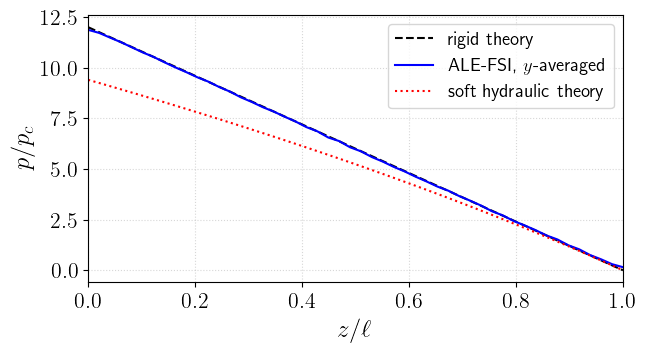

In [150]:
num_x_samples = 50
x_vals = np.linspace(0, l, num_x_samples)
avg_p = []

# Loop over x-values and average over vertical direction
for x_loc in x_vals:
    # Define a narrow vertical strip around x_loc
    strip_width = 1/(2*N)  # something small compared to domain size
    indicator = Expression("fabs(x[0] - x_loc) < w ? 1.0 : 0.0",
                           x_loc=x_loc, w=strip_width, degree=1)
    indicator_func = interpolate(indicator, p.function_space())

    # Compute weighted average
    weighted_integral = assemble(p * indicator_func * dx(FLUID_FLAG))
    area = assemble(indicator_func * dx(FLUID_FLAG))

    avg_p.append(weighted_integral / area if area > DOLFIN_EPS else 0.0)

avg_p = np.array(avg_p)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c), 
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c), 
        label='soft hydraulic theory', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()


## Fluid&ndash;solid interface displacement and pressure

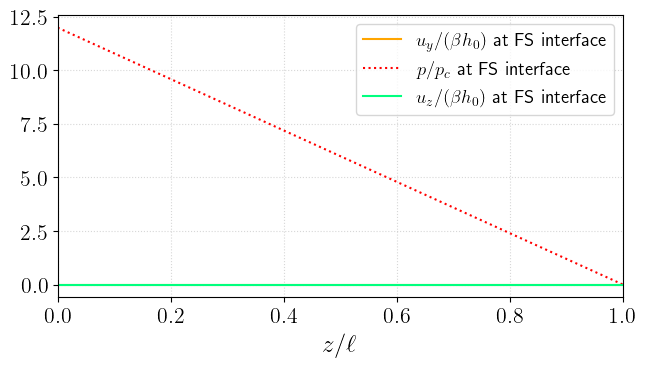

In [ ]:
# Create points along the fluid-solid interface:
# (offset down by ~1/N if needed, to ensure we're in the fluid domain)
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = []
p_fs_values = []
for point in fs_line_points:
    u_fs_values.append(u(point))
    p_fs_values.append(p(point))

u_fs_values = np.array(u_fs_values)
p_fs_values = np.array(p_fs_values)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, u_fs_values[:,1]/float(beta*h0),
        label=r'$u_y/(\beta h_0)$ at FS interface', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c), 
        label='$p/p_c$ at FS interface', color='red', linestyle='dotted')
ax.plot(x_vals/l, u_fs_values[:,0]/float(beta*h0),
        label=r'$u_z/(\beta h_0)$ at FS interface', color='springgreen')

ax.set_xlabel(r'$z/\ell$')
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()    

## Pressure contours

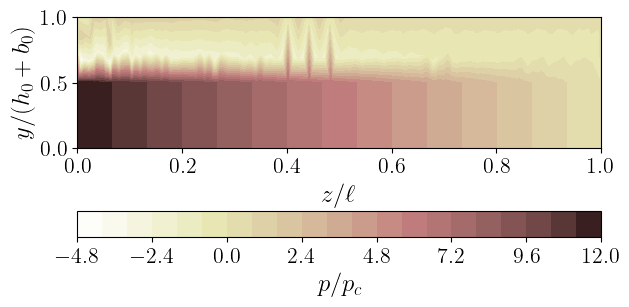

In [ ]:
# Get pressure values at vertices:
pressure_values = p.compute_vertex_values(mesh)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c), levels=20, cmap='pink_r')
fig.colorbar(contour,label='$p/p_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

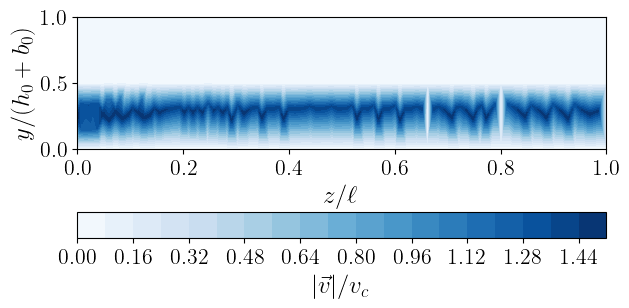

In [ ]:
# Get velocity values at vertices:
vx, vy = v.split()
vx_values = vx.compute_vertex_values(mesh)
vy_values = vy.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(vx_values**2 + vy_values**2)

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c), levels=20, cmap='Blues')
fig.colorbar(contour,label=r'$|\vec{v}|/v_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We will mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

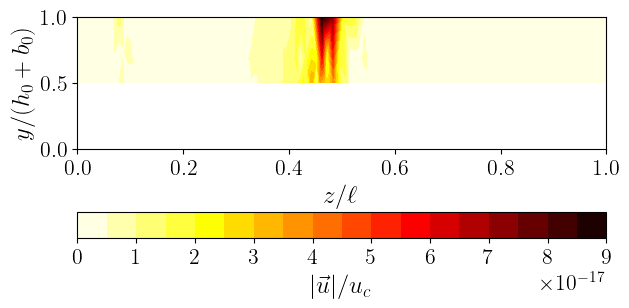

In [ ]:
# Get displacement values at vertices:
ux, uy = u.split(True)
ux_values = ux.compute_vertex_values()
uy_values = uy.compute_vertex_values()

# Compute magnitude:
magnitude = np.sqrt(ux_values**2 + uy_values**2)
# Mask off fluid domain, need to deep copy the triang:
masked_triang =  tri.Triangulation(x_coords.copy(), y_coords.copy(), cells.copy())
masked_triang.set_mask(np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(beta*h0), levels=20, cmap='hot_r')

fig.colorbar(contour,label=r'$|\vec{u}|/u_c$',orientation='horizontal')
ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()